In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Salary_Dataset_with_Extra_Features.csv")

## Data cleaning and analysis

In [3]:
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [4]:
df.shape

(22770, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22770 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [6]:
df.describe()

,Rating,Salary,Salaries Reported
count,22770.000000,2.277000e+04,22770.000000
mean,3.918213,6.953872e+05,1.855775
std,0.519675,8.843990e+05,6.823668
min,1.000000,2.112000e+03,1.000000
25%,3.700000,3.000000e+05,1.000000
50%,3.900000,5.000000e+05,1.000000
75%,4.200000,9.000000e+05,1.000000
max,5.000000,9.000000e+07,361.000000


In [7]:
df.isnull().sum()

Rating               0
Company Name         0
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.columns = ['rating', 'companyName', 'jobTitle', 'salary', 'salariesReported', 'location', 'status', 'roles']

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rating            22770 non-null  float64
 1   companyName       22770 non-null  object 
 2   jobTitle          22770 non-null  object 
 3   salary            22770 non-null  int64  
 4   salariesReported  22770 non-null  int64  
 5   location          22770 non-null  object 
 6   status            22770 non-null  object 
 7   roles             22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [11]:
df['companyName'].value_counts().head()  #Top 5 companies reported

Tata Consultancy Services         271
Amazon                            184
Infosys                           169
Accenture                         150
Cognizant Technology Solutions    144
Name: companyName, dtype: int64

In [12]:
df['jobTitle'].value_counts().head()  #Top 5 Roles reported

Software Development Engineer          2351
Android Developer                      2029
Software Development Engineer (SDE)    1614
Front End Developer                    1412
Test Engineer                          1314
Name: jobTitle, dtype: int64

## checking outliers

Text(0.5, 1.0, 'salary')

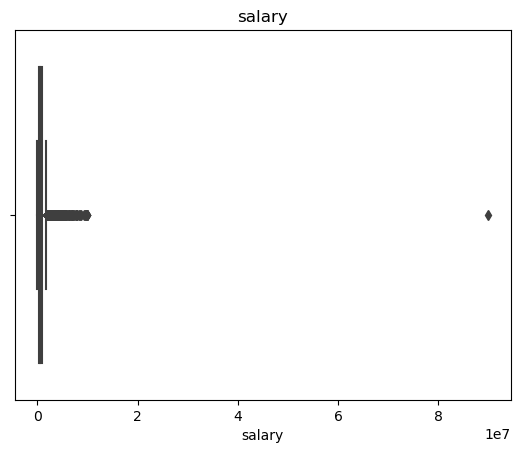

In [13]:
plt
sns.boxplot(data = df, x = 'salary')
plt.title('salary')

In [14]:
def outlier_police(data, column):
    '''
    Function to check the ouliers.
    It will return the outliers from both upper and lower threshold
    '''
    
    q3 = data[column].quantile(0.75)
    q1 = data[column].quantile(0.25)
    iqr = q3 - q1
    upper_threshold = q3 + (1.5 * iqr)
    lower_threshold = q1 - (1.5 * iqr)

    outliers_upper = data[data[column] > upper_threshold]
    outliers_lower = data[data[column] < lower_threshold]

    # Concatenate the two DataFrames
    all_outliers = pd.concat([outliers_upper, outliers_lower], ignore_index=True)

    return all_outliers

In [15]:
outlier = pd.DataFrame(outlier_police(df,'salary'))

In [16]:
outlier

,rating,companyName,jobTitle,salary,salariesReported,location,status,roles
0,4.1,Dunzo,Android Developer,2800000,1,Bangalore,Full Time,Android
1,4.0,Walmart Global Tech,Android Developer,2300000,1,Bangalore,Full Time,Android
2,4.1,First Student,Android Developer - Intern,2200000,1,Bangalore,Intern,Android
3,4.4,Microsoft,Android Developer,2100000,1,Bangalore,Full Time,Android
4,3.7,Paytm Money,Android Developer,1900000,1,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
1151,3.9,Western Digital,Web Developer,2400000,1,Bangalore,Full Time,Web
1152,4.1,HealthGraph India,Web Developer,4400000,1,Bangalore,Full Time,Web
1153,2.9,Sud Express,Web Developer,2900000,1,Bangalore,Full Time,Web
1154,4.2,Greytip,Web Developer,2100000,1,Bangalore,Full Time,Web


In [17]:
##EDA

Text(0.5, 1.0, 'salary')

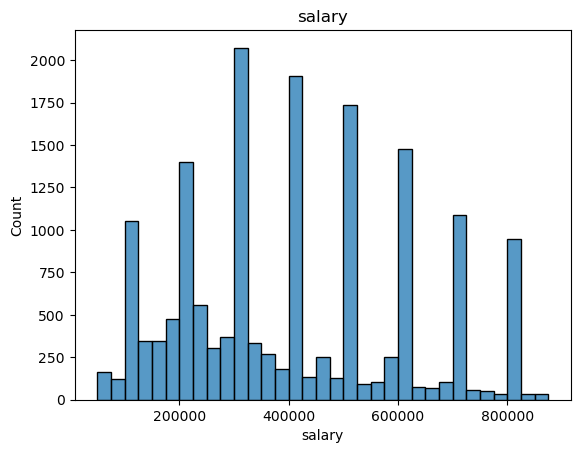

In [47]:
sns.histplot(data = df, x = 'salary', bins = range(50000, 900000,25000))
plt.title('salary')

It follows a normal distribution

In [19]:
df['jobTitle'].value_counts()

Software Development Engineer          2351
Android Developer                      2029
Software Development Engineer (SDE)    1614
Front End Developer                    1412
Test Engineer                          1314
                                       ... 
Java Andriod Developer                    1
Java Deceloper                            1
Java/J2EE Programmer                      1
Java SOA Developer                        1
Associate Web Developer                   1
Name: jobTitle, Length: 1080, dtype: int64

In [20]:
df.groupby(by='location')['salary'].agg('mean')

location
Bangalore         735344.739593
Chennai           584559.661513
Hyderabad         679099.157376
Jaipur            629135.802469
Kerala            553577.481481
Kolkata           710925.573034
Madhya Pradesh    677641.909677
Mumbai            961180.368491
New Delhi         658756.735632
Pune              690476.311153
Name: salary, dtype: float64

It seems outliers are affecting the mean salaries. Removing the outliers to check if the mean is affected by the outliers

In [21]:
def remove_outliers(data, column):
    q3 = data[column].quantile(0.75)
    q1 = data[column].quantile(0.25)
    iqr = q3 - q1
    upper_threshold = q3 + (1.5 * iqr)
    lower_threshold = q1 - (1.5 * iqr)

    # Remove outliers by filtering the data
    data_no_outliers = data[(data[column] >= lower_threshold) & (data[column] <= upper_threshold)]

    return data_no_outliers


In [22]:
df_cleaned = pd.DataFrame(remove_outliers(df,'salary'))

df_cleaned.shape

(21614, 8)

In [23]:
df_cleaned.groupby(by='location')['salary'].agg('mean')

location
Bangalore         606592.401189
Chennai           523388.068763
Hyderabad         571350.134149
Jaipur            566153.846154
Kerala            514965.735849
Kolkata           566359.281437
Madhya Pradesh    505600.644295
Mumbai            752751.976155
New Delhi         564724.843308
Pune              594584.661125
Name: salary, dtype: float64

In [24]:
df_cleaned.head()

,rating,companyName,jobTitle,salary,salariesReported,location,status,roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [25]:
df1 = df_cleaned.copy()

In [26]:
df1.head()

,rating,companyName,jobTitle,salary,salariesReported,location,status,roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


## Rating

<AxesSubplot: xlabel='rating', ylabel='Count'>

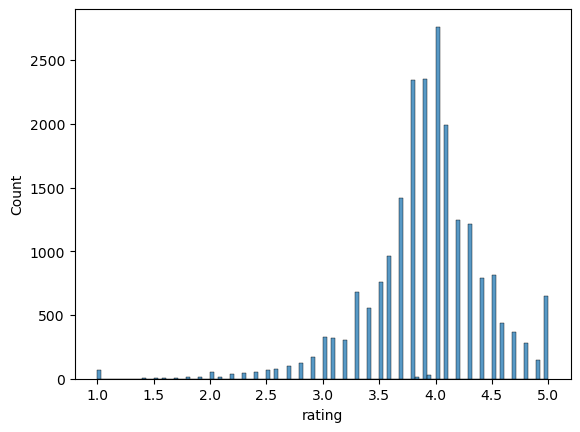

In [27]:
sns.histplot(data = df1, x = 'rating')

In [28]:
df1['rating'] = np.floor(df1['rating'])

In [29]:
df1.head(5)

,rating,companyName,jobTitle,salary,salariesReported,location,status,roles
0,3.0,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.0,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.0,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.0,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [30]:
df1.groupby(by='rating')['salary'].agg('count')

rating
1.0      115
2.0      734
3.0    10062
4.0    10054
5.0      649
Name: salary, dtype: int64

In [31]:
df1['rating'].value_counts(normalize=True)

3.0    0.465532
4.0    0.465161
2.0    0.033959
5.0    0.030027
1.0    0.005321
Name: rating, dtype: float64

1 represents 1 - 1.99
2 represents - 2 - 2.99
3 represents - 3 - 3.99
4 represents - 4 - 4.99
5 represents - 5 - 5.99


93 percentage of people falls 3 and 4 rating

# AVERAGE SALARY BY LOCATION

In [32]:
df1.groupby(by='location')['salary'].agg('mean')

location
Bangalore         606592.401189
Chennai           523388.068763
Hyderabad         571350.134149
Jaipur            566153.846154
Kerala            514965.735849
Kolkata           566359.281437
Madhya Pradesh    505600.644295
Mumbai            752751.976155
New Delhi         564724.843308
Pune              594584.661125
Name: salary, dtype: float64

In [33]:
salary_loc = df1.groupby(by='location').agg({'salary':'mean'}).reset_index()

In [34]:
salary_loc = salary_loc.sort_values(by= 'salary', ascending=False)


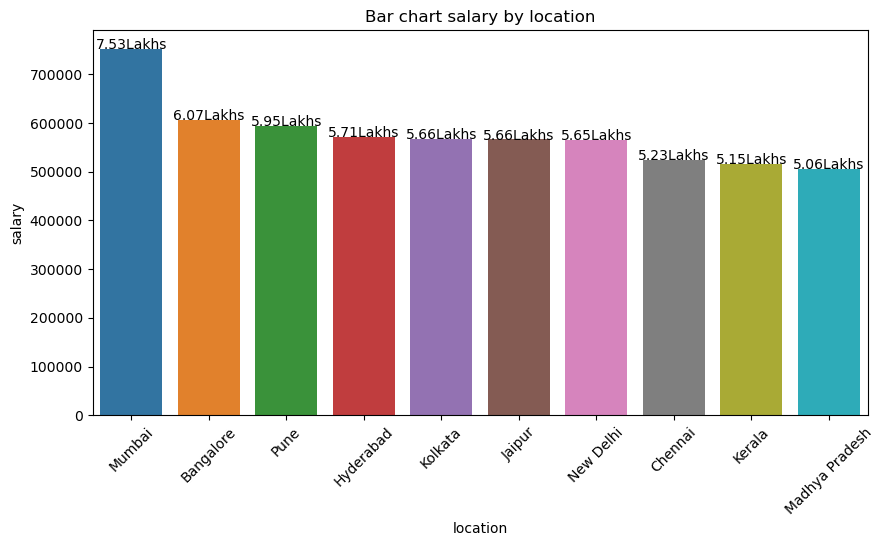

In [35]:
plt.figure(figsize=(10,5))
sns.barplot(data = salary_loc, x = 'location', y = 'salary')
plt.title("Bar chart salary by location")
plt.xticks(rotation = 45)
for index, value in enumerate(salary_loc['salary']):
    plt.text(index, value + 1, str(round(value/100000,2))+'Lakhs', ha='center')
plt.show()



Mumbai, bangalore and pune has the highhest salary average 

# ROLES AND SALARY

In [36]:
roles_loc = df1.groupby(by='roles').agg({'salary':'mean'}).reset_index()

In [37]:
roles_loc = roles_loc.sort_values(by= 'salary', ascending=False)

In [38]:
roles_loc

,roles,salary
2,Database,745670.833333
8,SDE,693104.775386
6,Mobile,648251.121076
4,IOS,617741.013470
1,Backend,574203.926740
3,Frontend,532927.754789
0,Android,501886.106443
5,Java,493755.957895
9,Testing,474144.130006
7,Python,460101.327641


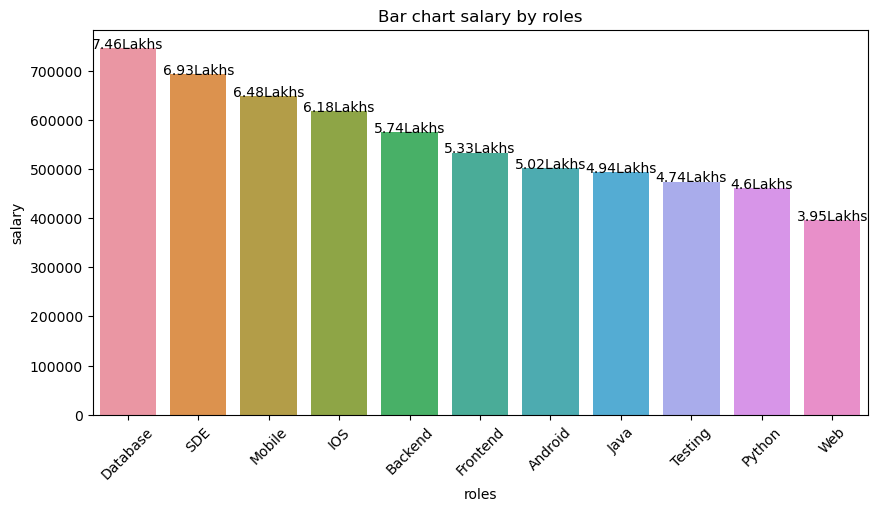

In [39]:
plt.figure(figsize=(10,5))
sns.barplot(data = roles_loc, x = 'roles', y = 'salary')
plt.title("Bar chart salary by roles")
plt.xticks(rotation = 45)
for index, value in enumerate(roles_loc['salary']):
    plt.text(index, value + 1, str(round(value/100000,2))+'Lakhs', ha='center')
plt.show()


In [40]:
df1.head(5)

,rating,companyName,jobTitle,salary,salariesReported,location,status,roles
0,3.0,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.0,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.0,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.0,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [41]:
#status and salary
#roles in each location
#credibility for each salary
#roles and status - bar


# status and salary

In [42]:
status_sal = df1.groupby(by='status').agg({'salary':'mean'}).reset_index().sort_values(by= 'salary', ascending=False)

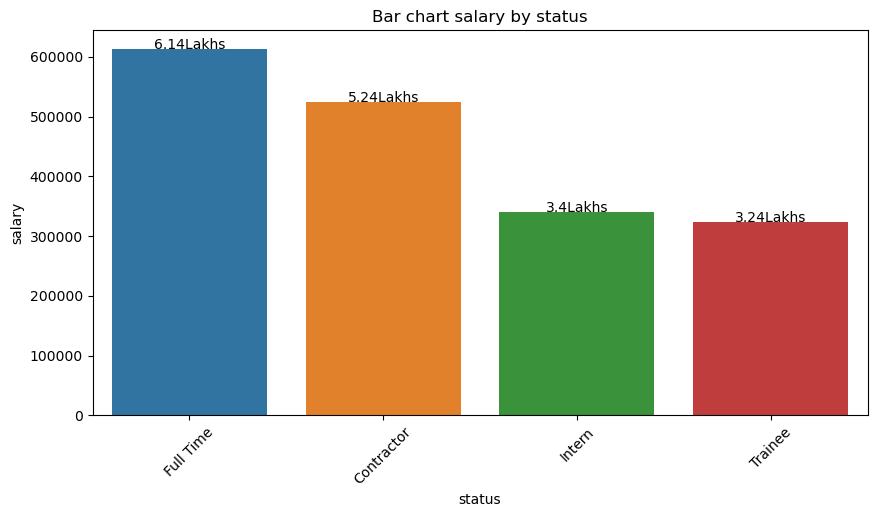

In [43]:
plt.figure(figsize=(10,5))
sns.barplot(data = status_sal, x = 'status', y = 'salary')
plt.title("Bar chart salary by status")
plt.xticks(rotation = 45)
for index, value in enumerate(status_sal['salary']):
    plt.text(index, value + 1, str(round(value/100000,2))+'Lakhs', ha='center')
plt.show()


In [44]:
df1['salariesReported'].value_counts()

1      17272
2       2304
3        743
4        353
5        216
       ...  
76         1
39         1
291        1
361        1
280        1
Name: salariesReported, Length: 79, dtype: int64

In [45]:
df1['location'].value_counts()

Bangalore         7737
Hyderabad         4249
New Delhi         4027
Chennai           2385
Pune              2045
Mumbai             671
Kolkata            167
Madhya Pradesh     149
Kerala             106
Jaipur              78
Name: location, dtype: int64